# Spectral Analysis per Subphases

In [1]:
import os
import pandas as pd
import numpy as np
import spectrogram_functions as spectr

In [2]:
route_in = 'C:/Users/alvar/Desktop/Discrete_validation/out_data'

dirs = []
for folder in os.listdir(route_in):
    dirs.append(str(route_in + '/' + folder + '/filtered'))

save_path = 'C:/Users/alvar/Desktop/Discrete_validation/Spectrogram_analysis_results'
if not os.path.exists(save_path):
    os.makedirs(save_path)

C:/Users/alvar/Desktop/Discrete_validation/out_data/Patient_1/filtered

Stance_1_clean_EMG.csv
Stance_2_clean_EMG.csv
Stance_3_clean_EMG.csv
Swing_1_clean_EMG.csv
Swing_2_clean_EMG.csv
Swing_3_clean_EMG.csv
C:/Users/alvar/Desktop/Discrete_validation/out_data/Patient_10/filtered

Stance_1_clean_EMG.csv
Stance_2_clean_EMG.csv
Stance_3_clean_EMG.csv
Stance_4_clean_EMG.csv
Swing_1_clean_EMG.csv
Swing_2_clean_EMG.csv
Swing_3_clean_EMG.csv
Swing_4_clean_EMG.csv
C:/Users/alvar/Desktop/Discrete_validation/out_data/Patient_11/filtered

Stance_1_clean_EMG.csv
Stance_2_clean_EMG.csv
Swing_1_clean_EMG.csv
Swing_2_clean_EMG.csv
C:/Users/alvar/Desktop/Discrete_validation/out_data/Patient_12/filtered

Stance_1_clean_EMG.csv
Stance_2_clean_EMG.csv
Stance_3_clean_EMG.csv
Swing_1_clean_EMG.csv
Swing_2_clean_EMG.csv
Swing_3_clean_EMG.csv
C:/Users/alvar/Desktop/Discrete_validation/out_data/Patient_13/filtered

Stance_1_clean_EMG.csv
Stance_2_clean_EMG.csv
Stance_3_clean_EMG.csv
Stance_4_clean_EMG.csv
Swin

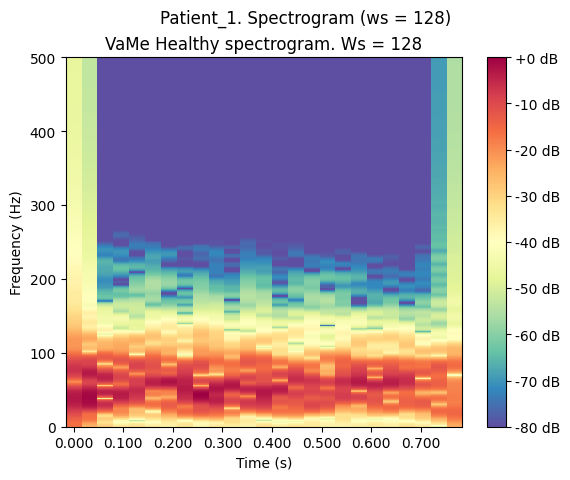

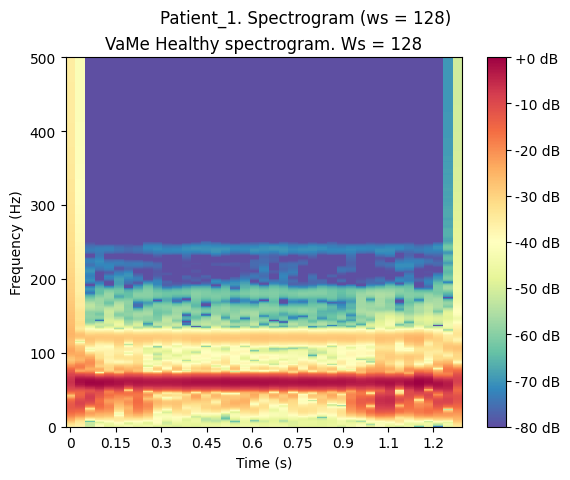

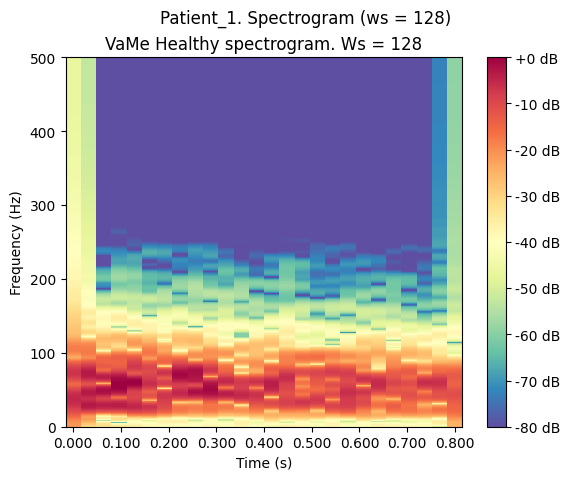

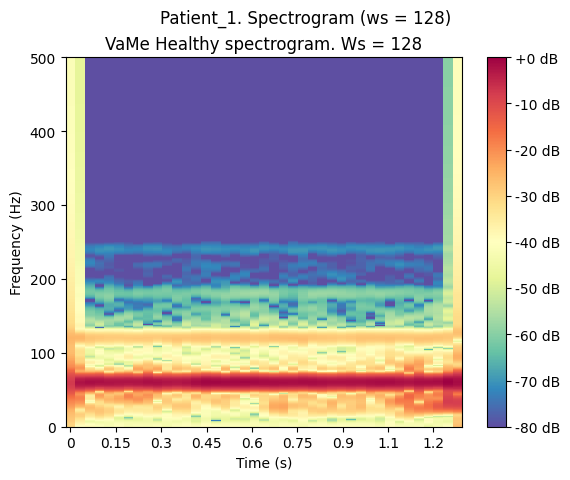

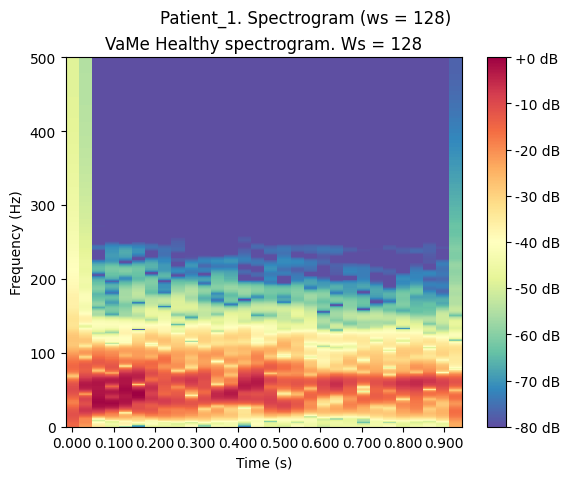

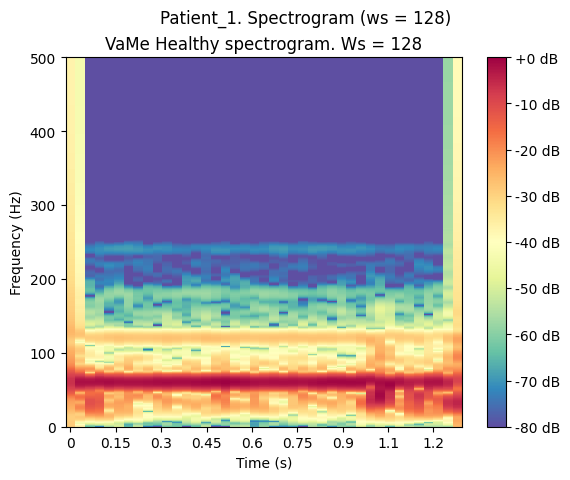

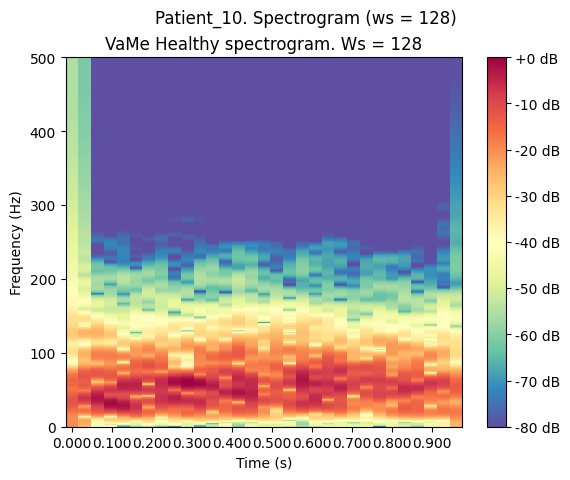

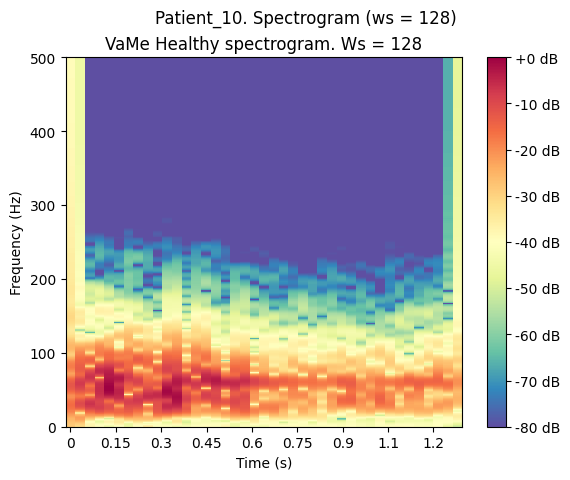

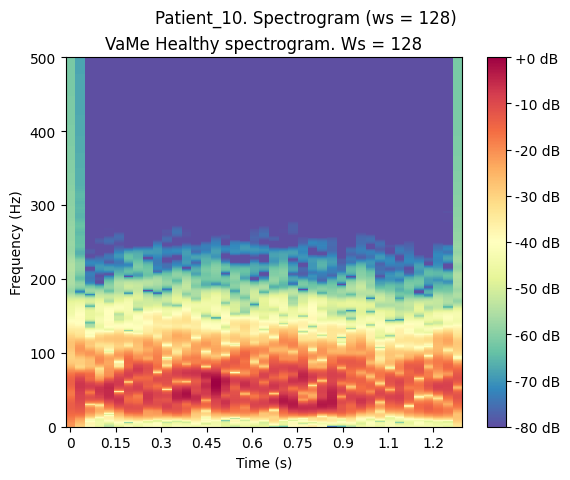

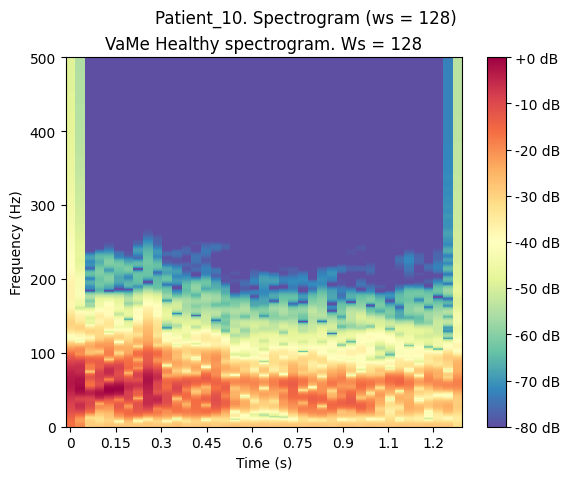

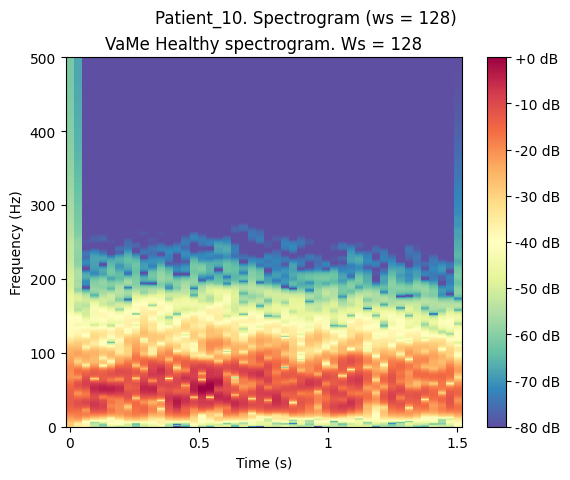

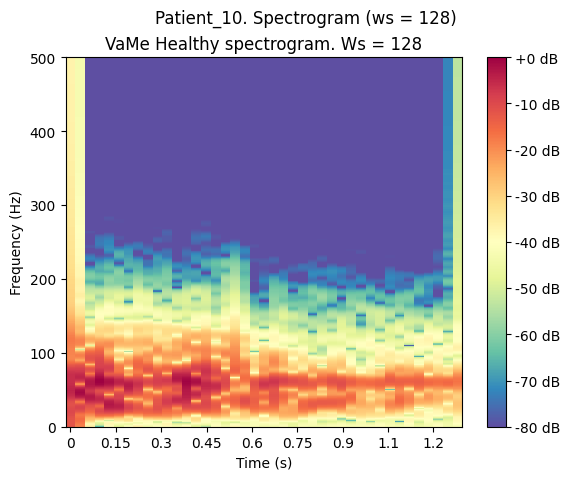

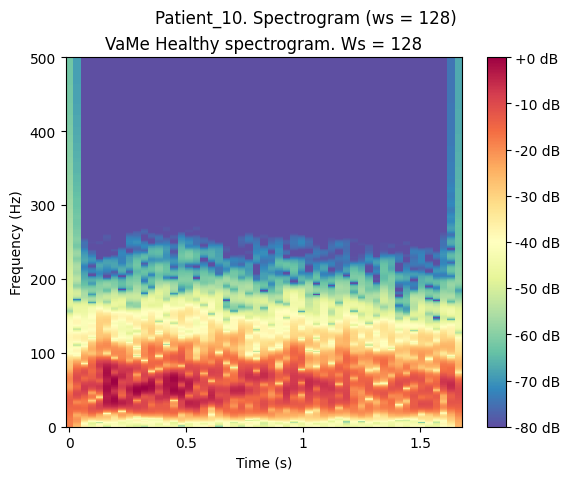

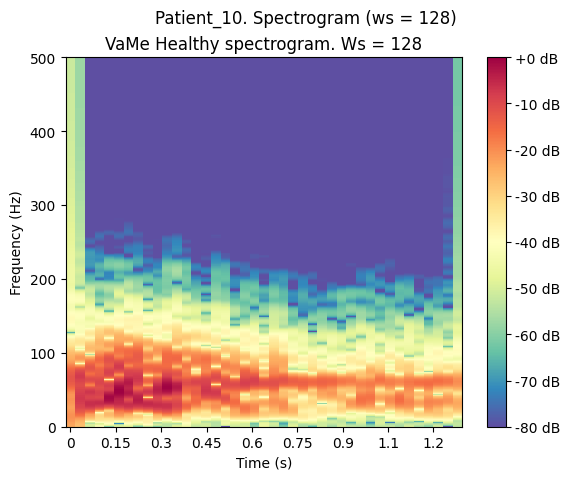

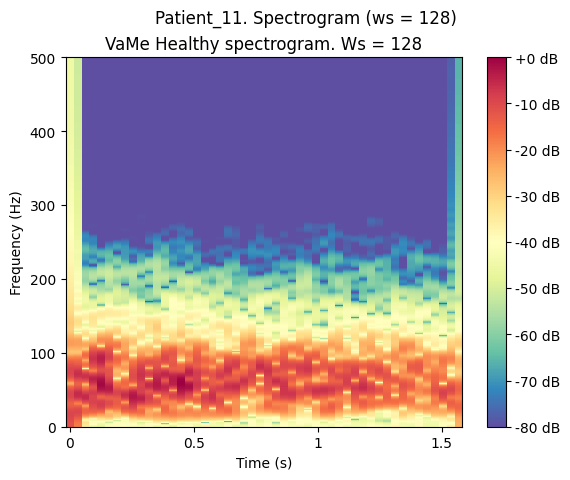

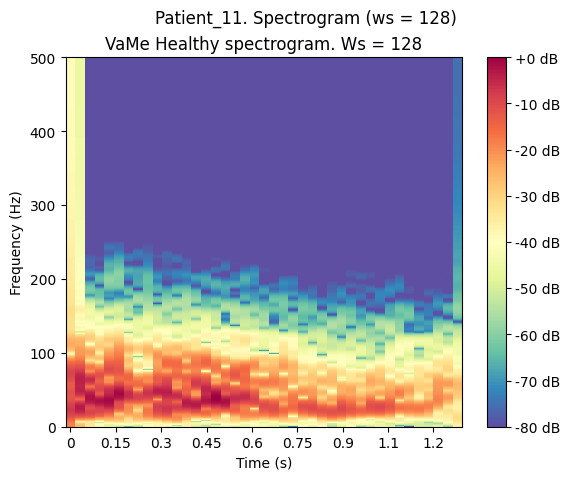

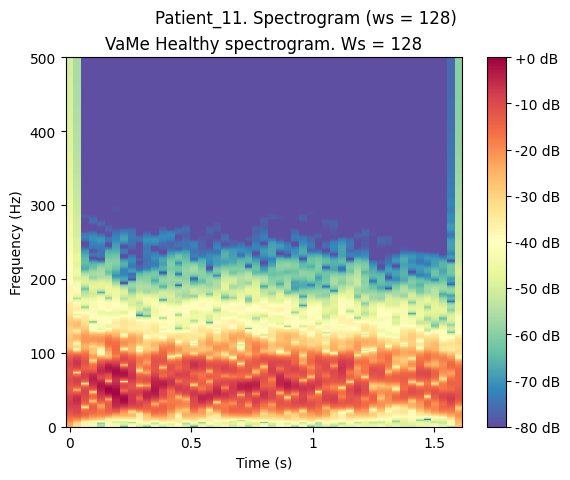

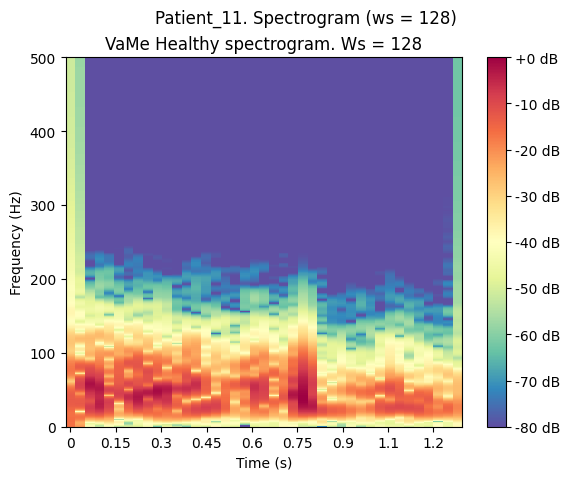

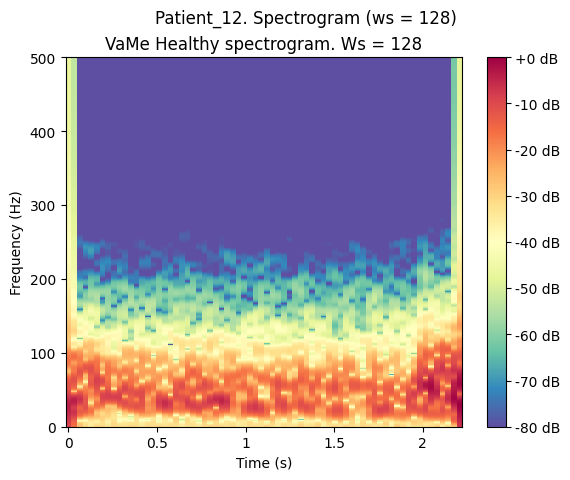

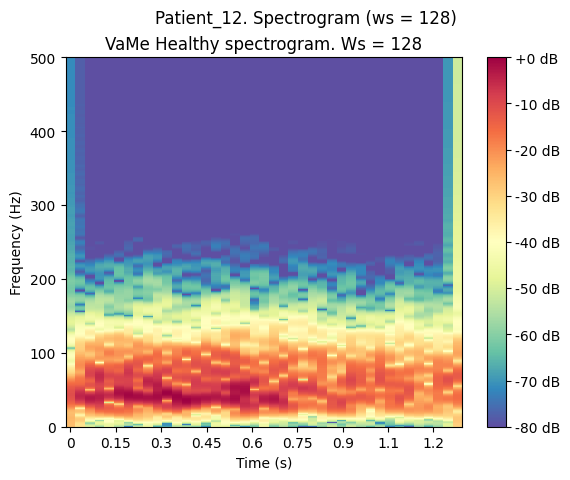

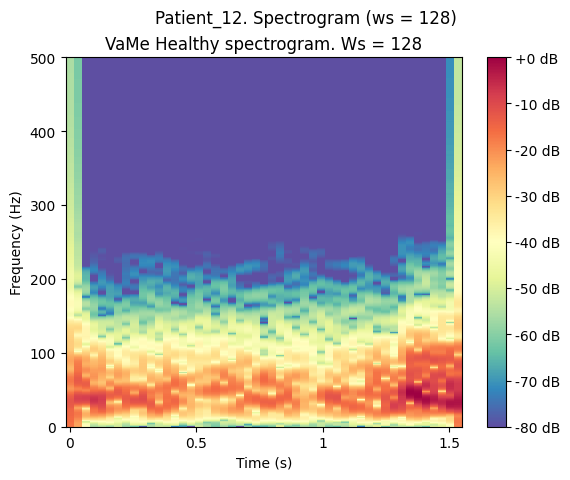

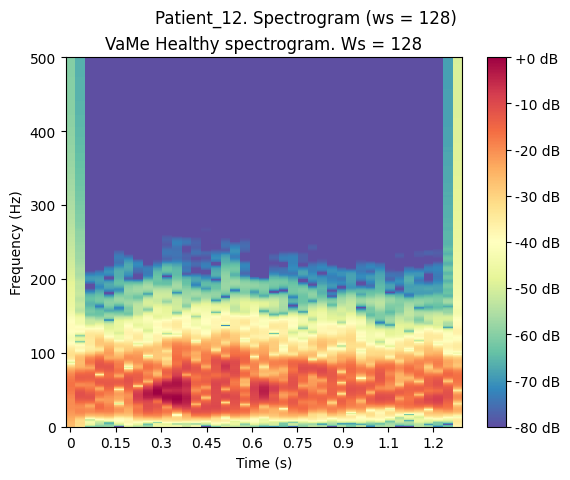

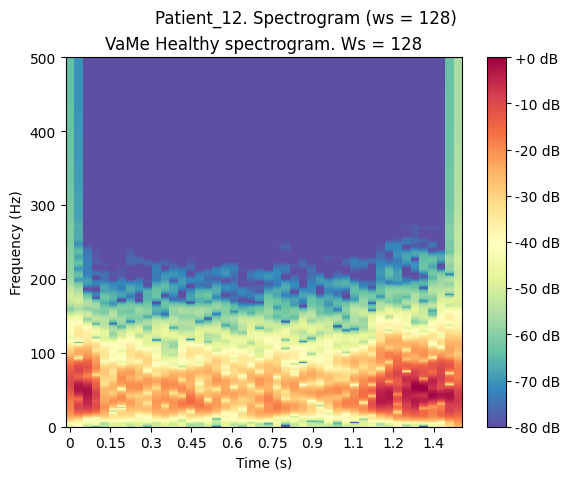

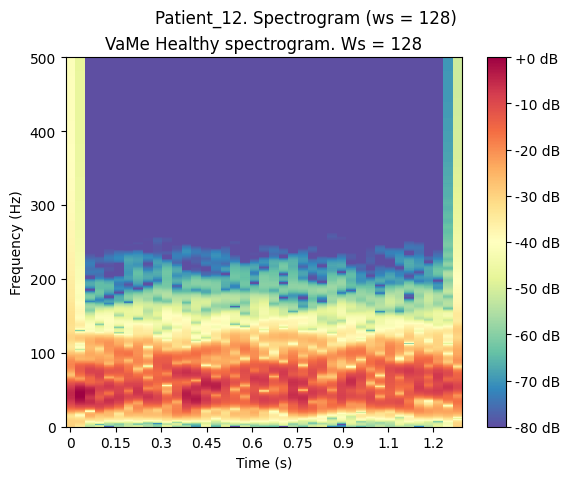

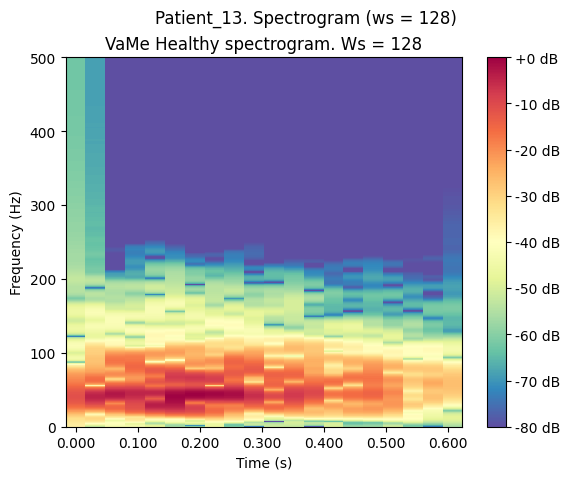

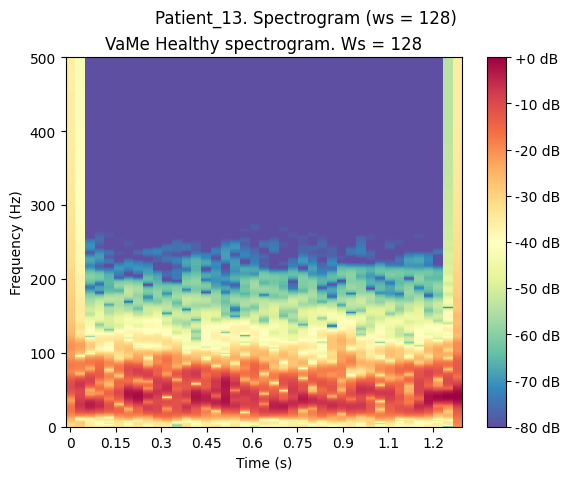

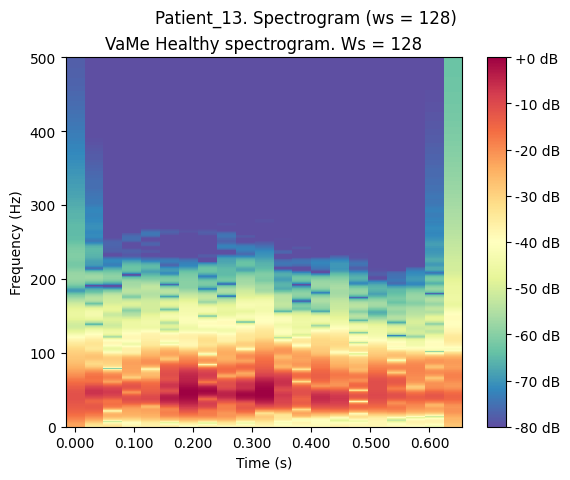

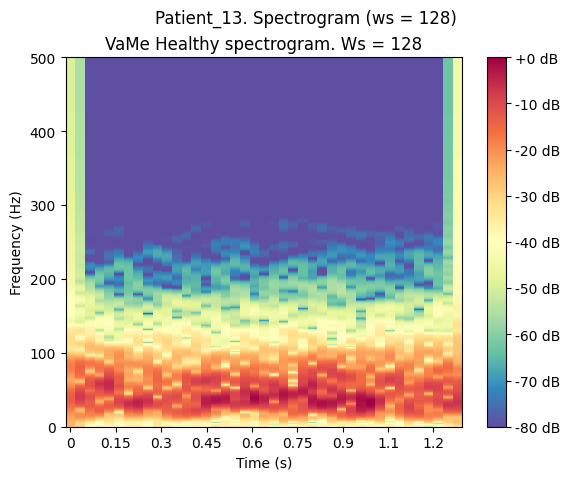

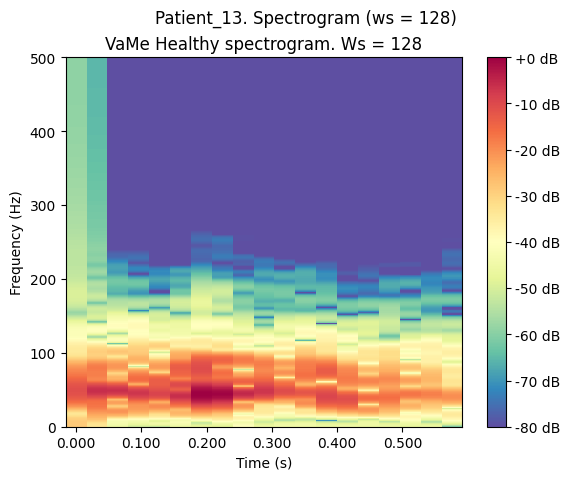

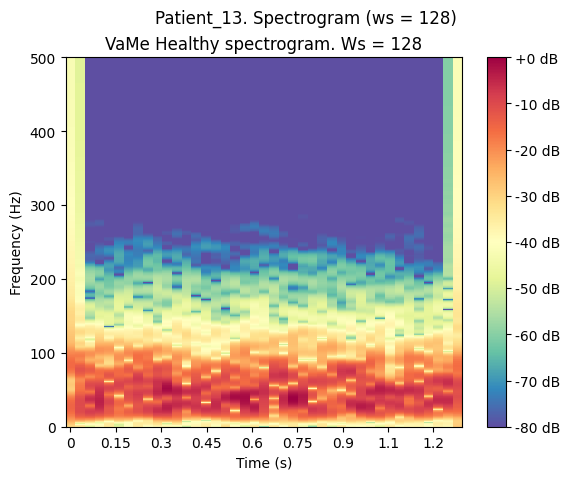

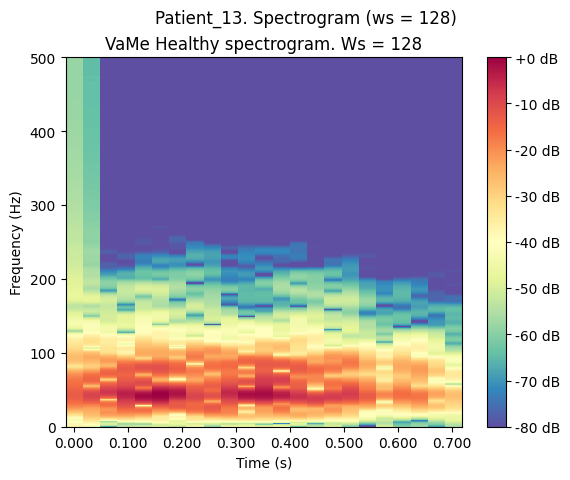

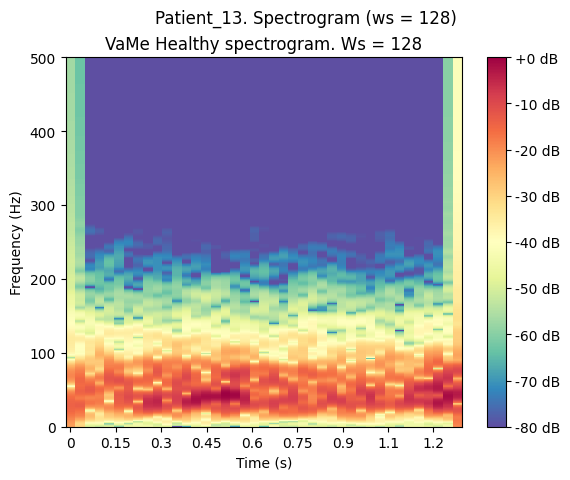

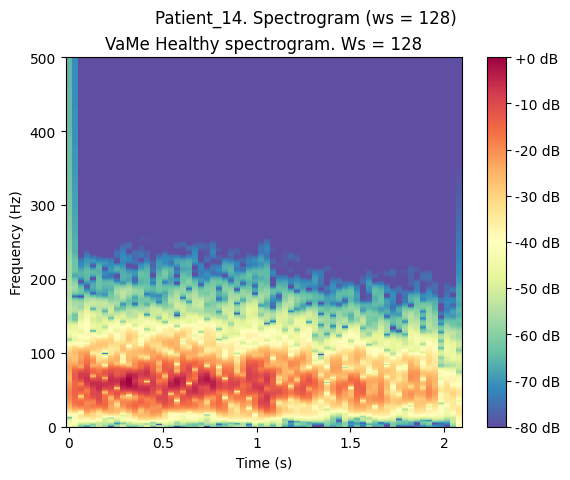

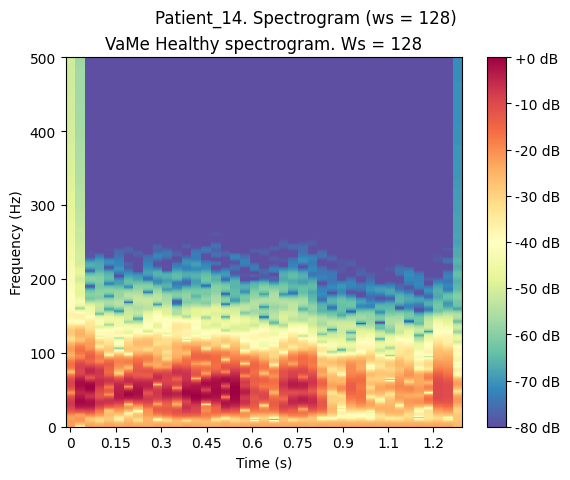

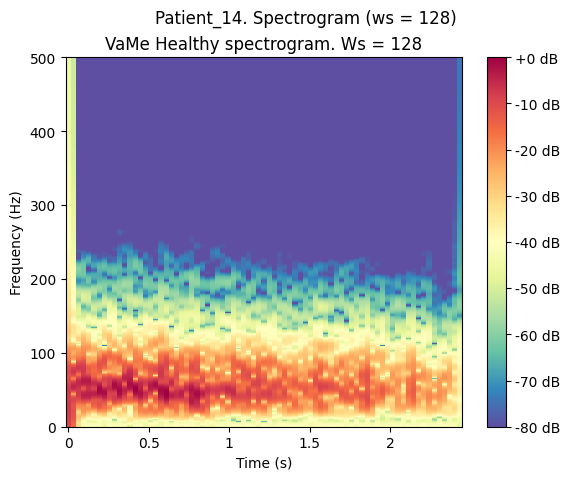

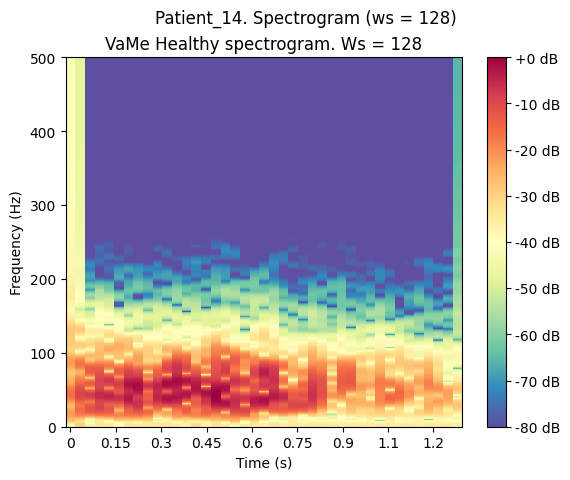

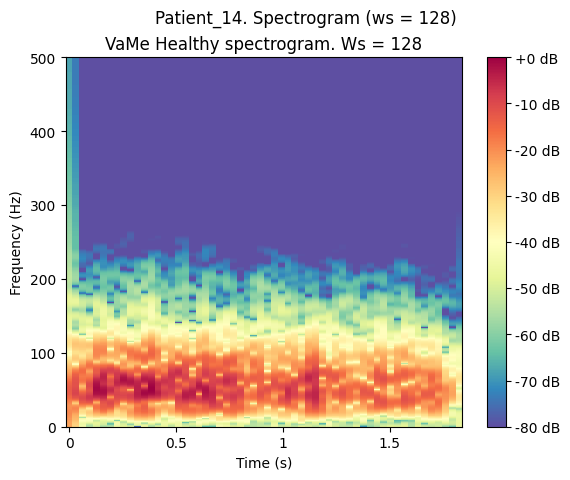

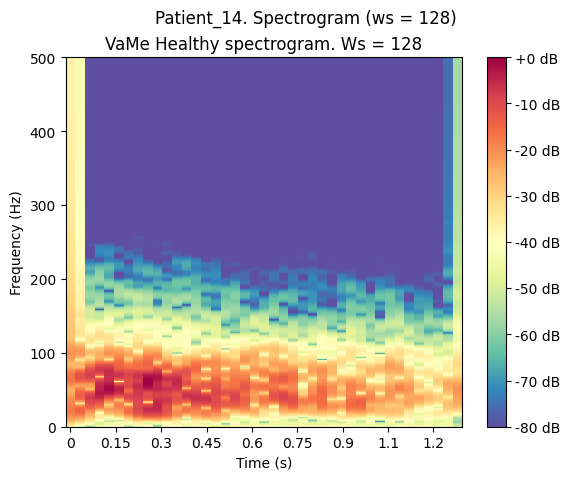

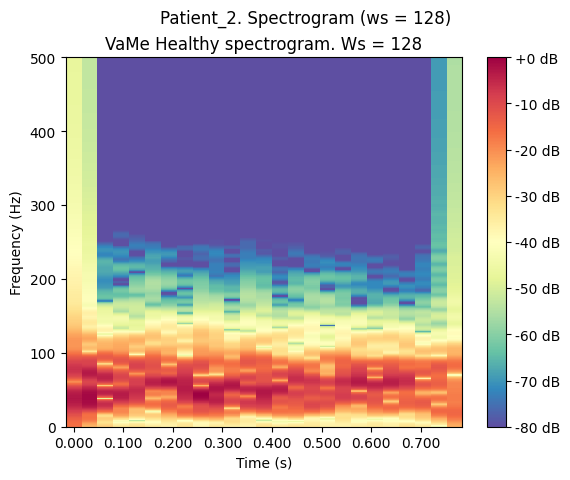

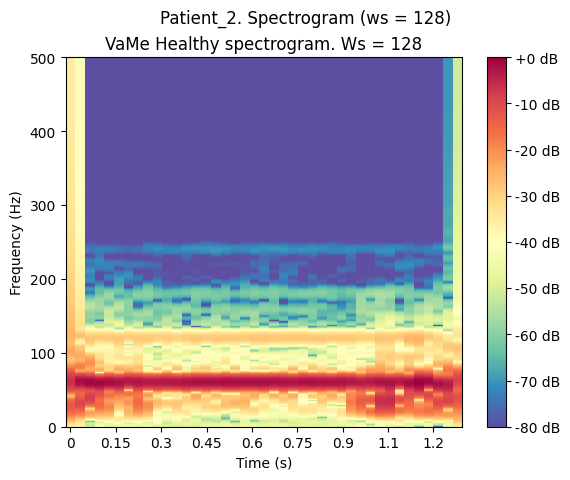

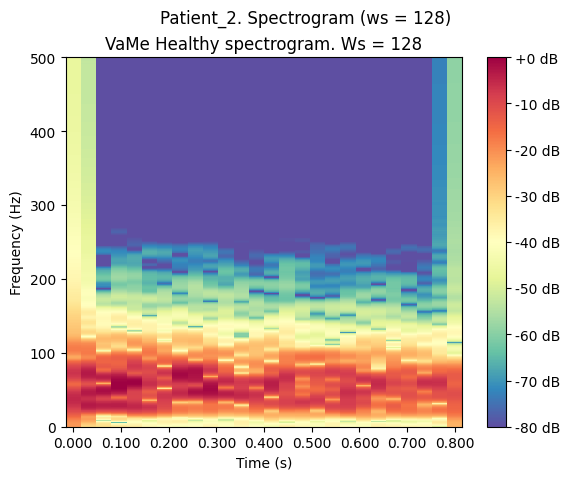

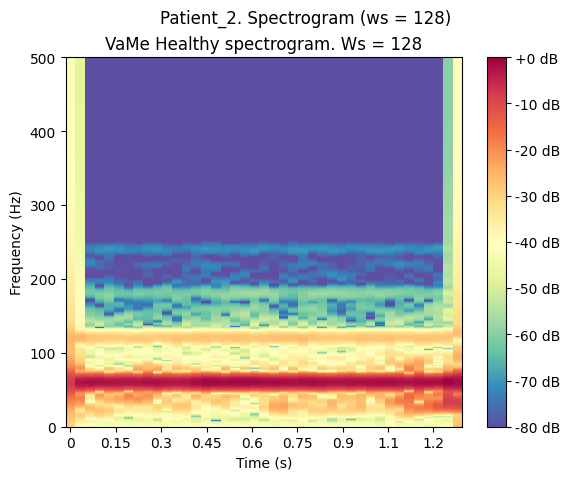

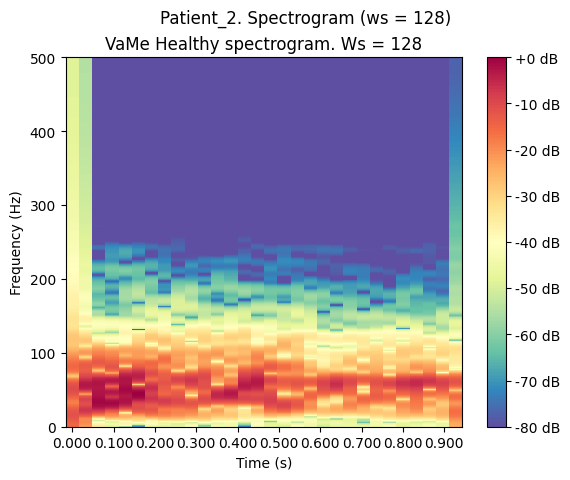

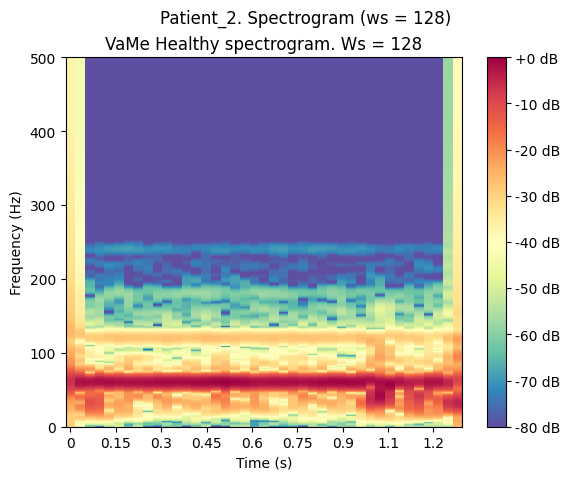

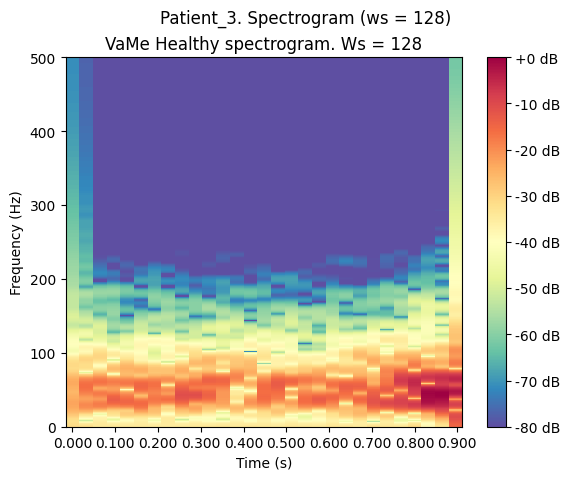

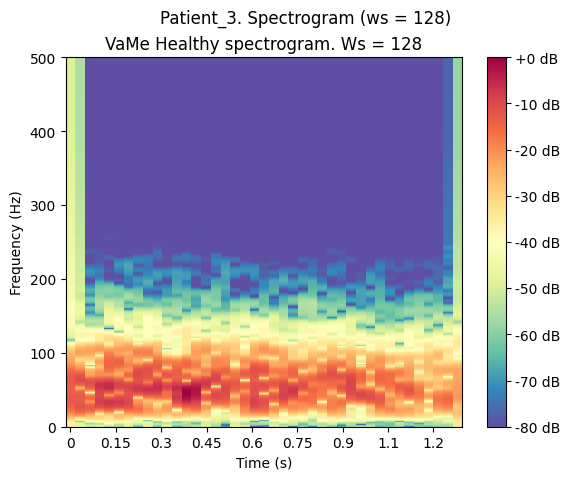

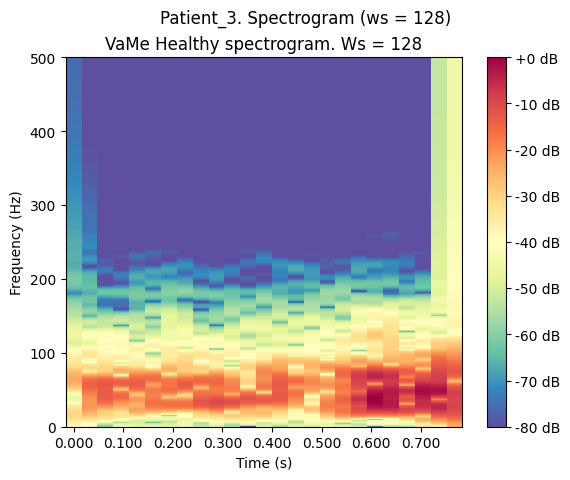

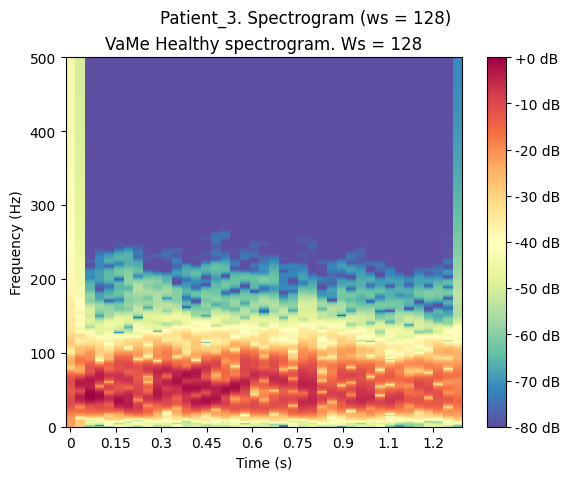

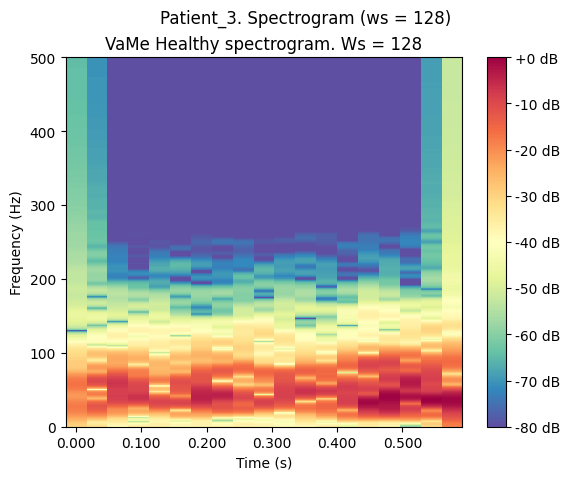

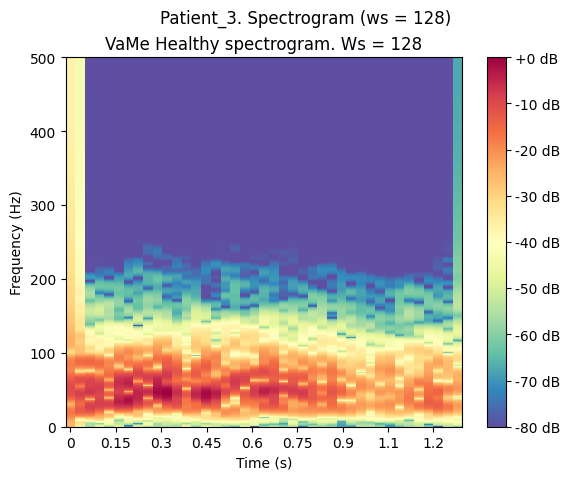

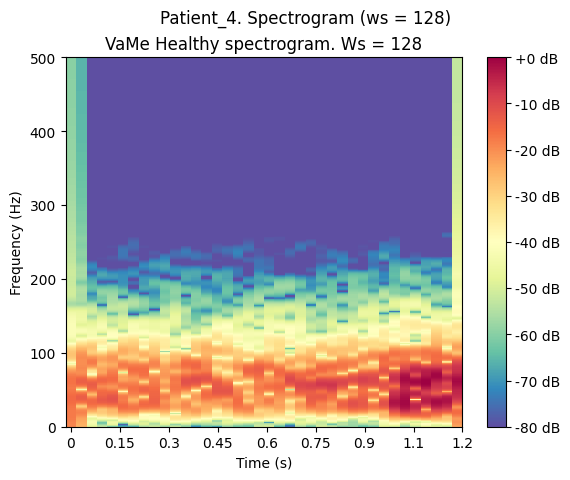

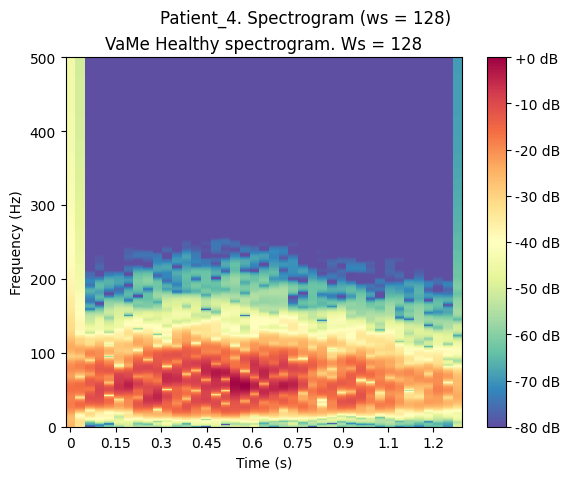

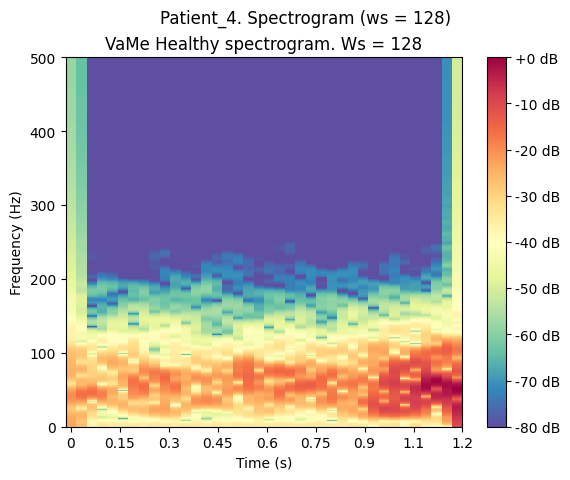

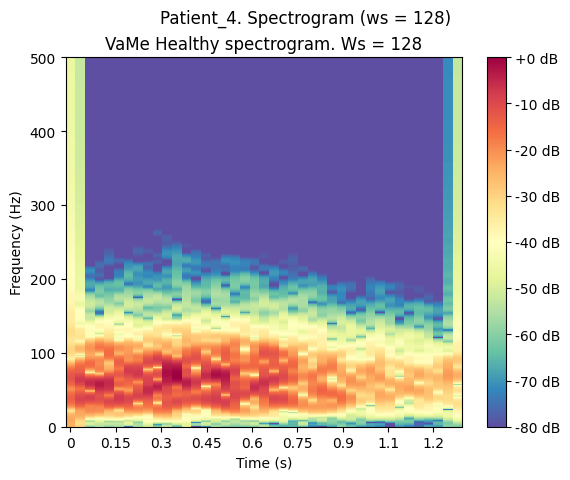

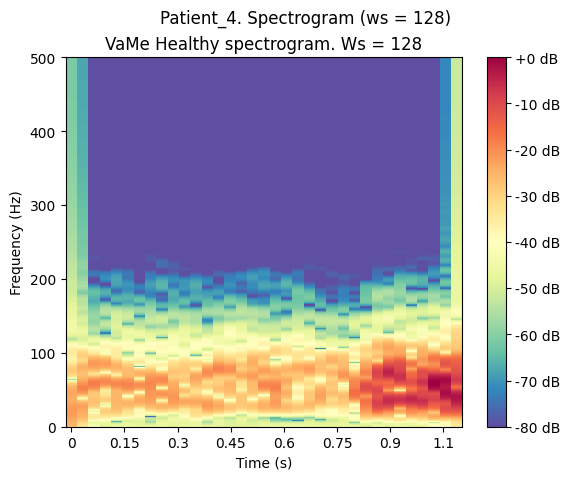

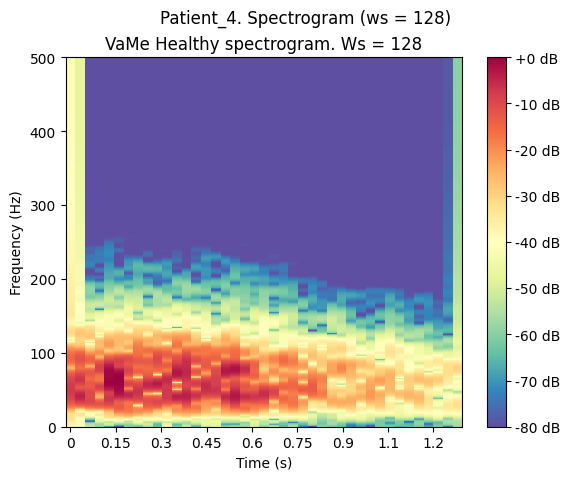

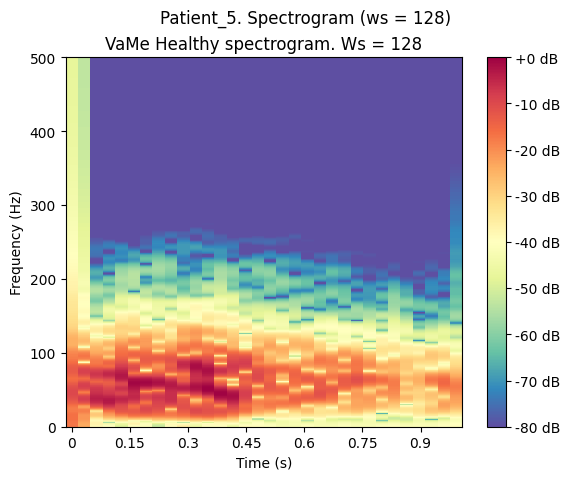

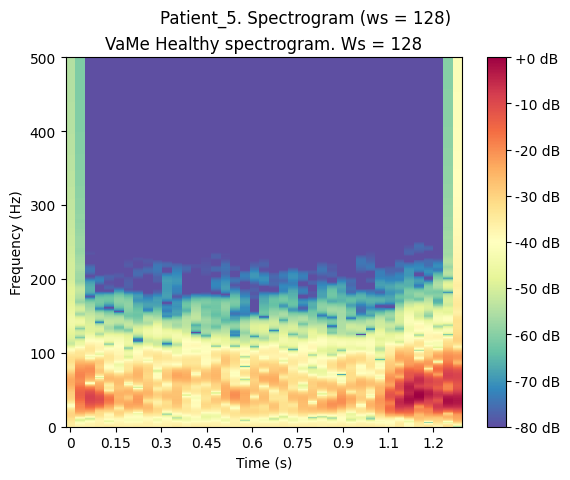

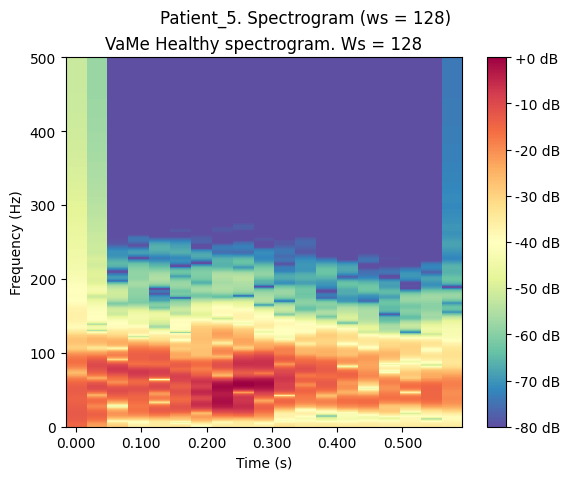

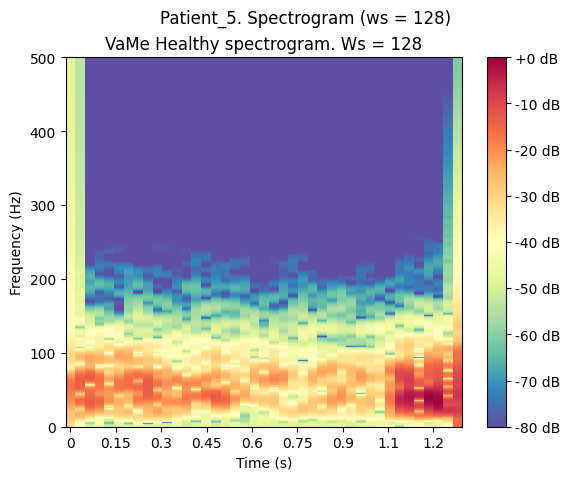

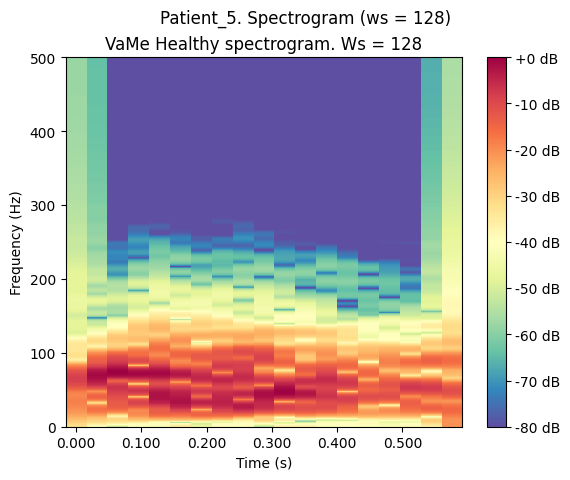

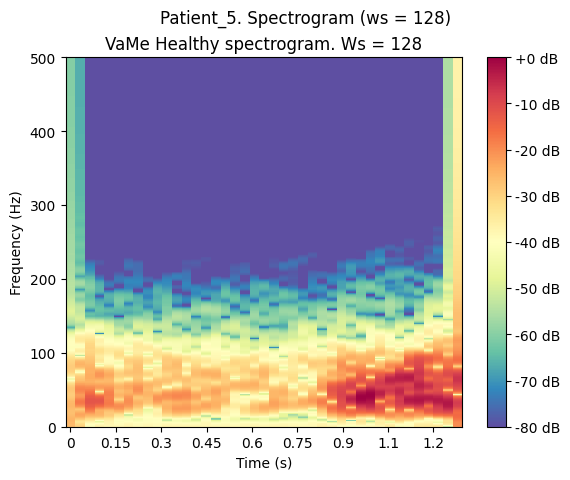

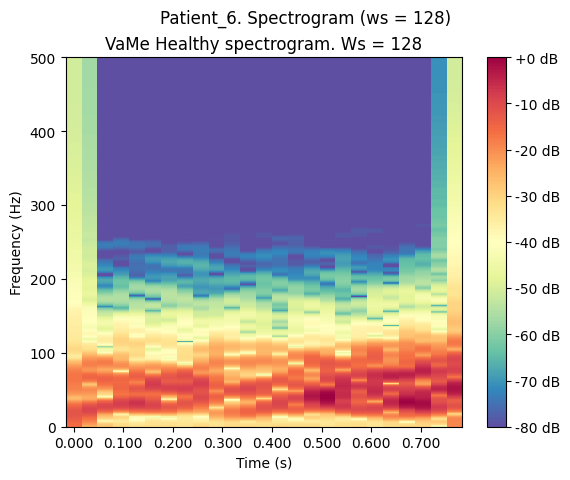

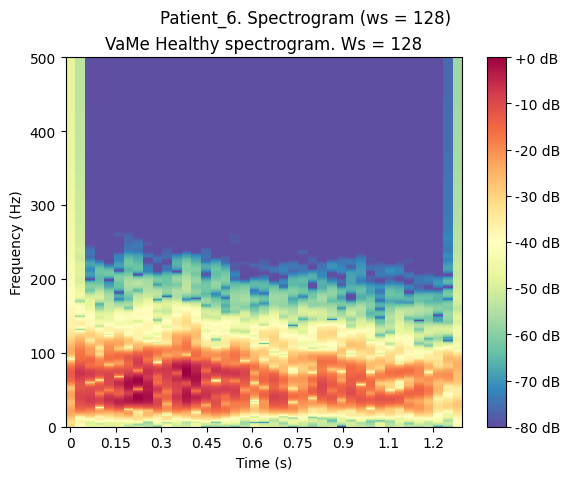

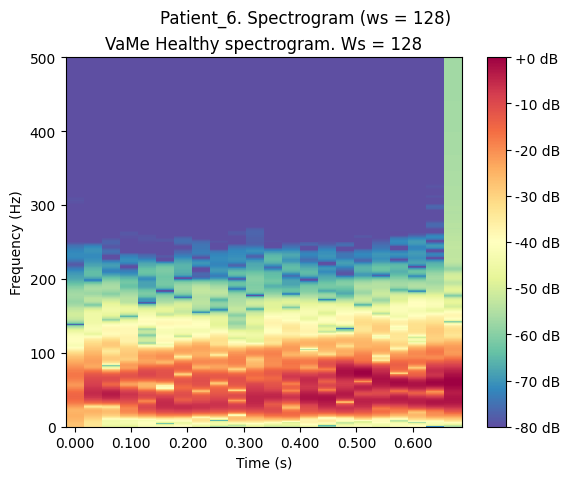

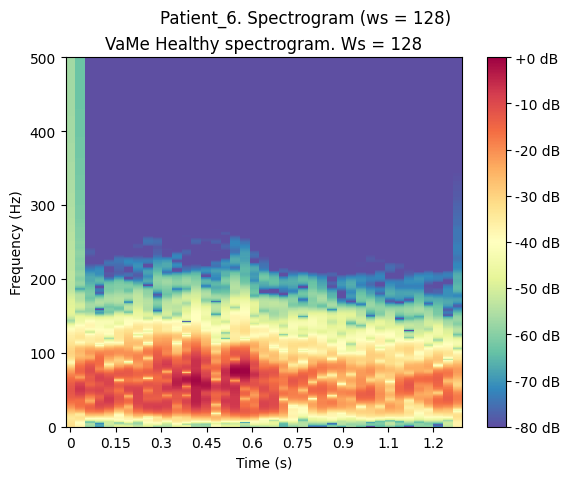

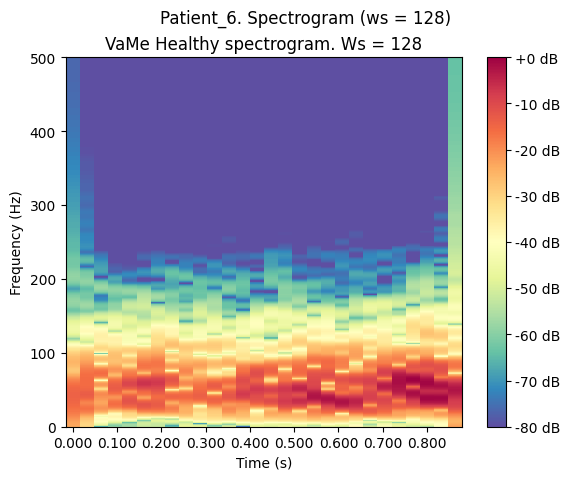

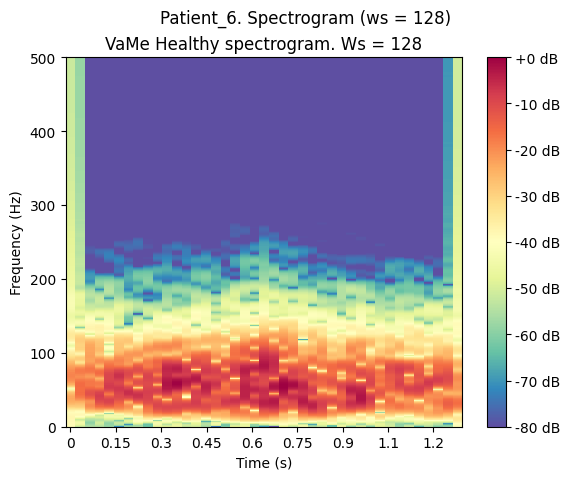

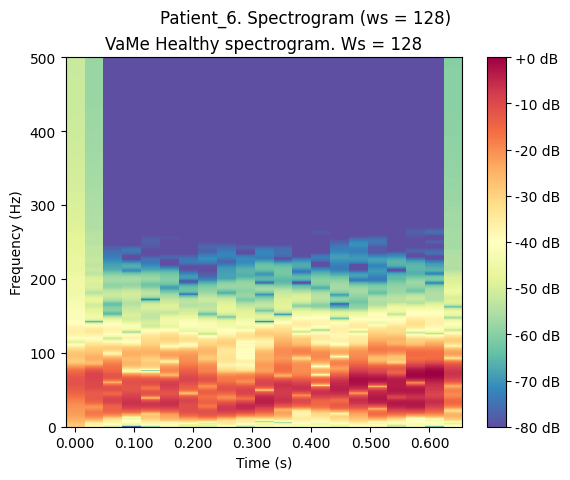

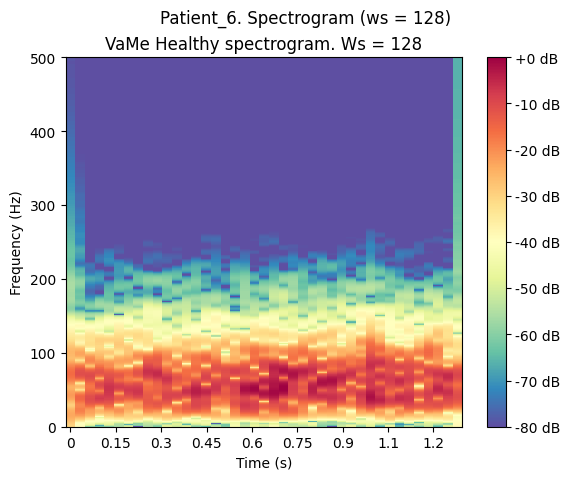

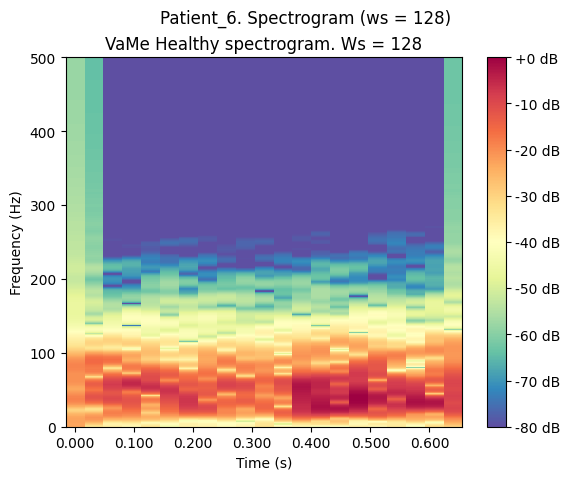

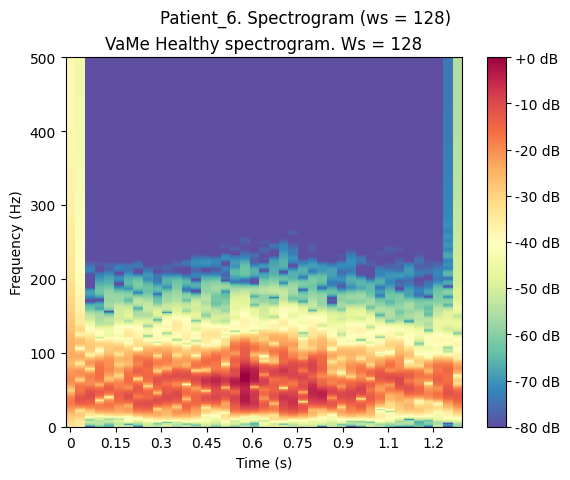

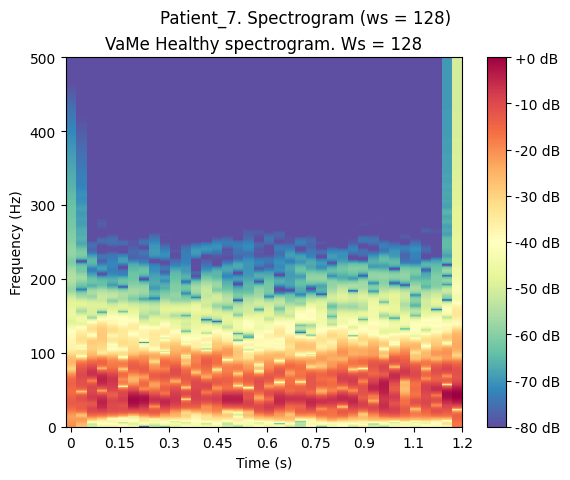

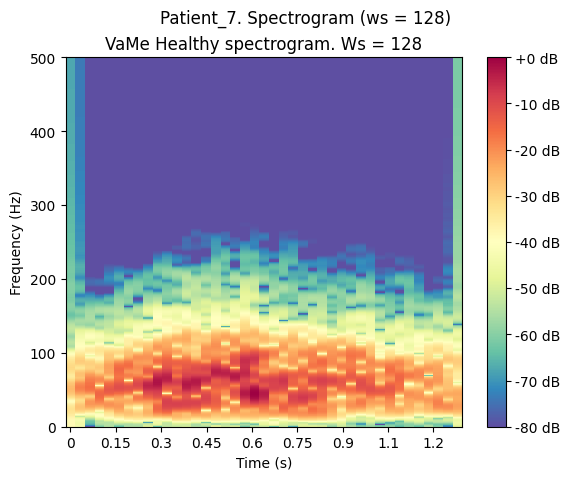

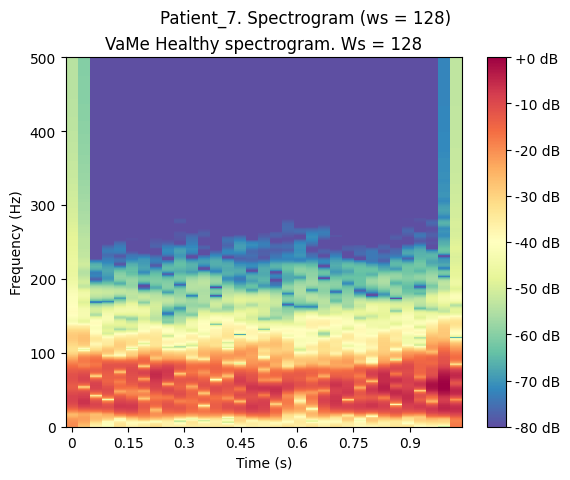

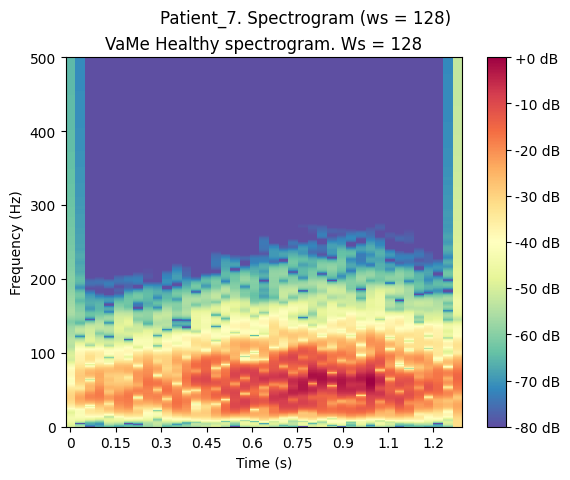

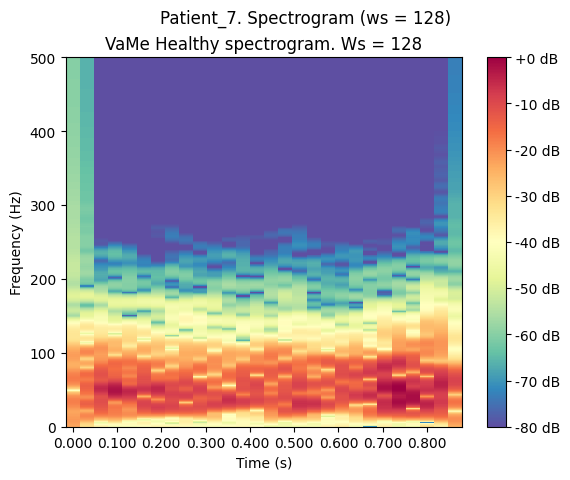

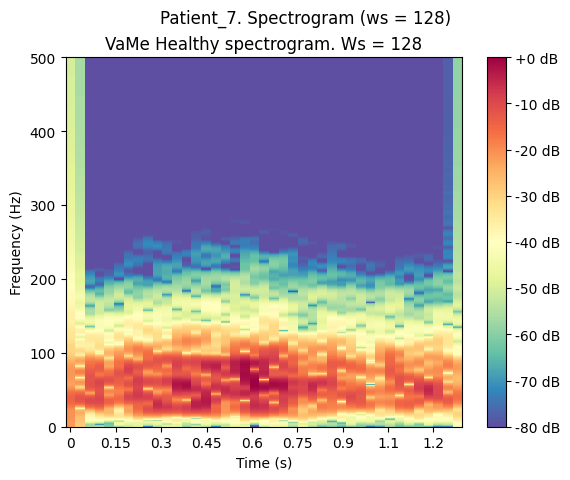

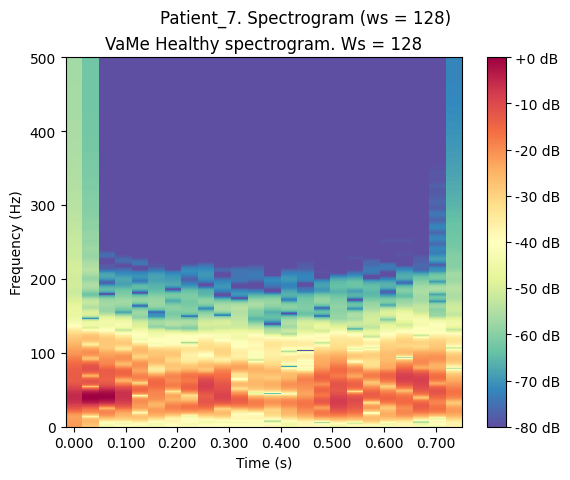

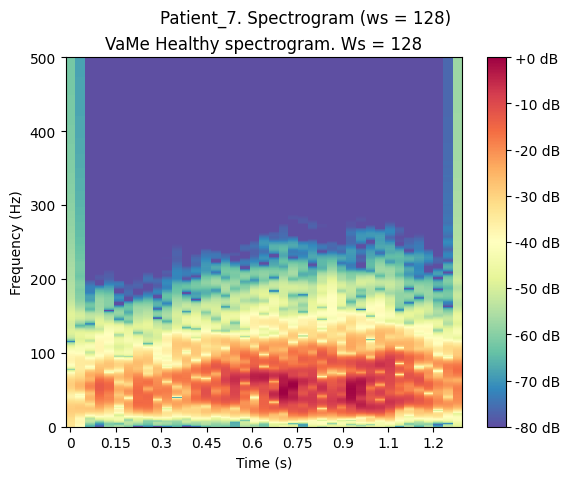

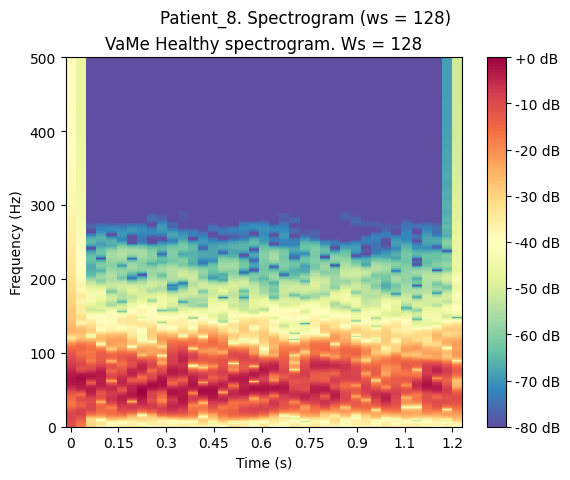

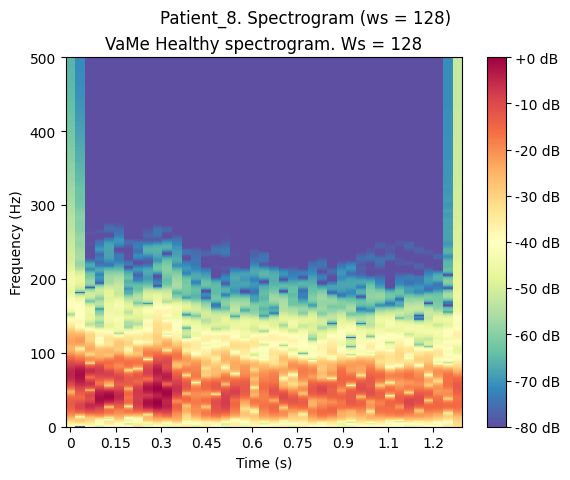

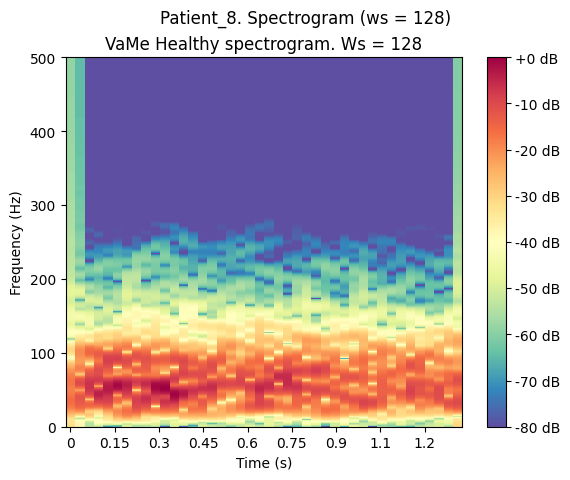

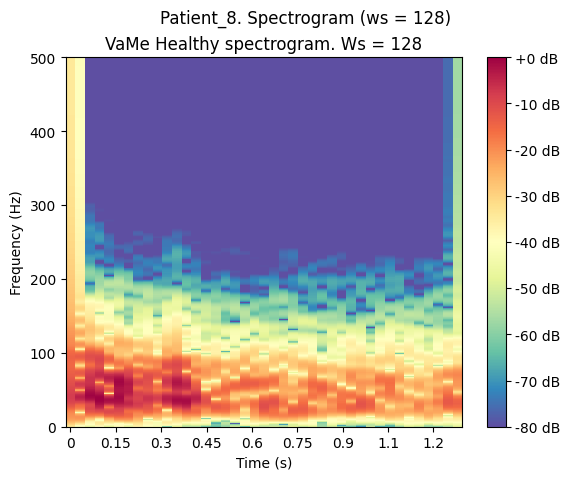

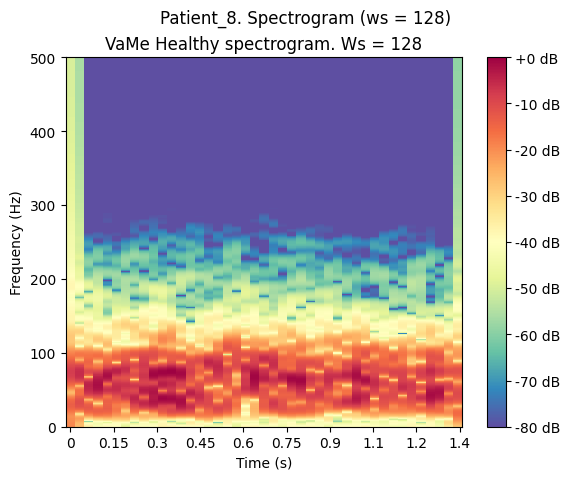

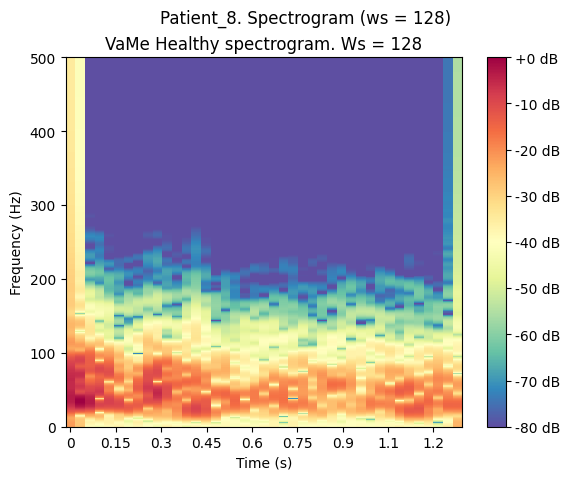

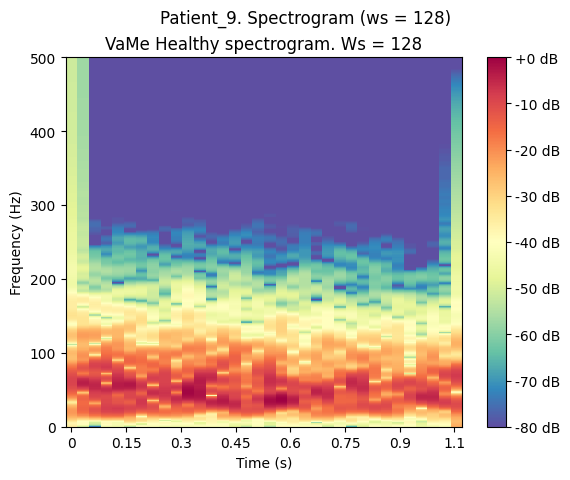

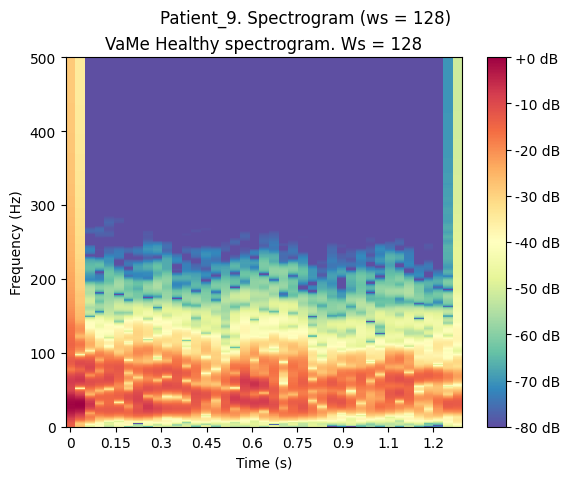

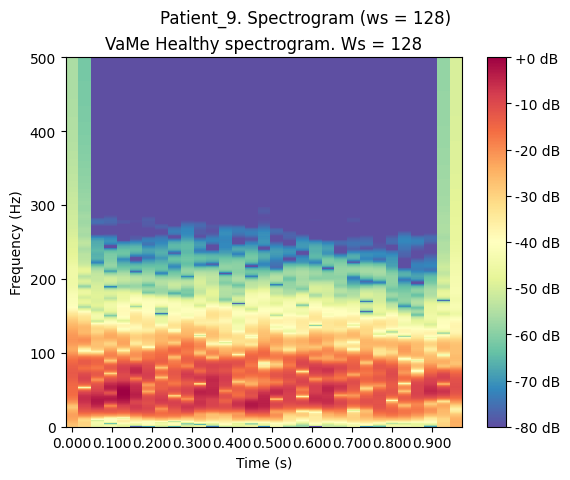

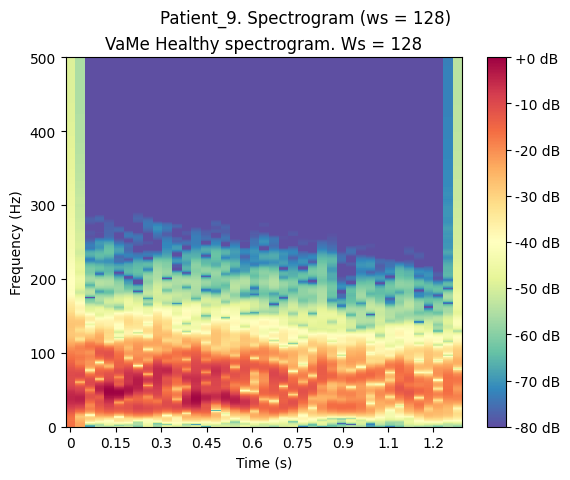

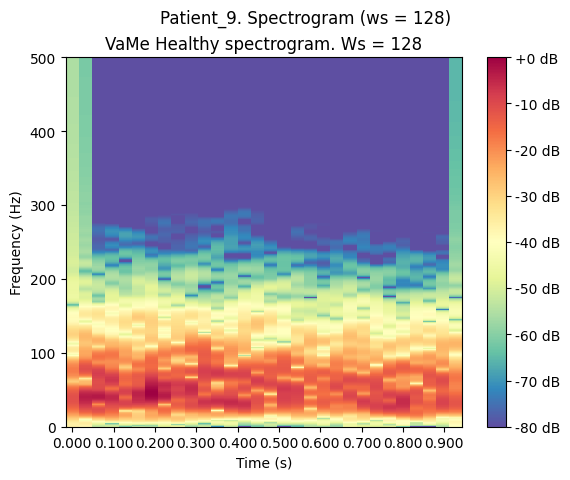

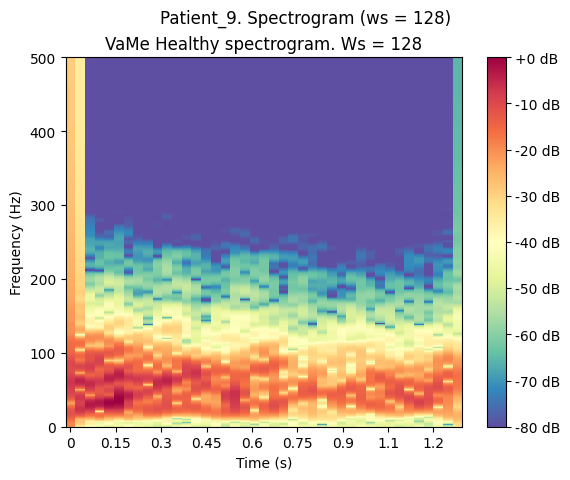

In [11]:
MNF_values = pd.DataFrame(columns = ['MNF_st','MNF_sw'])
MDF_values = pd.DataFrame(columns = ['MDF_st','MDF_sw'])
TP_values = pd.DataFrame(columns = ['TP_st','TP_sw'])
MNP_values = pd.DataFrame(columns = ['MNP_st','MNP_sw'])

index_df = ([])
list_mnf_st = ([])
list_mdf_st = ([])
list_mnf_sw = ([])
list_mdf_sw = ([])
strides = 0
sample_rate = 1000
selected_muscle = 'VaMe'
for x in range(0,len(dirs)):
    folder = dirs[x]
    print(str(folder) + '\n')

    files = os.listdir(folder)
    for file in files:
        print(file)
        if 'Stance' in file:
            EMG = pd.read_csv(folder + '/' + file)
            EMG_stance = EMG[selected_muscle]
            femg_stance = EMG_stance.to_numpy()

            wind_size = 128

            spectr.plot_1(femg_stance, folder, selected_muscle, 'None', 'FILTERED_stance', file[:-4], 'Healthy', save_path = save_path)
            psd_welch_st, f_welch_st = spectr.compute_psd_welch(femg_stance, sample_rate, 'plot', folder, selected_muscle, file[:-4], 'Healthy','st', save_path)
            spec_st = spectr.spec_librosa(femg_stance, wind_size, sample_rate, selected_muscle, 'plot', folder, file[:-4], 'Healthy', 'st', save_path)

            mnf_st = spectr.compute_mnf(femg_stance, sample_rate)
            MNF_values.at[str(folder) + '_' + str(file[:-4]), 'MNF_st'] = mnf_st
            list_mnf_st.append(mnf_st)

            tp_st = spectr.compute_tp(spec_st)
            TP_values.at[str(folder) + '_' + str(file[:-4]), 'TP_st'] = tp_st

            mnp_st = spectr.compute_mnp(spec_st)
            MNP_values.at[str(folder) + '_' + str(file[:-4]), 'MNP_st'] = mnp_st

            mdf_st = spectr.compute_mdf(femg_stance, sample_rate)
            MDF_values.at[str(folder) + '_' + str(file[:-4]), 'MDF_st'] = mdf_st
            list_mdf_st.append(mdf_st)
        
            swing_file = 'Swing' + file[6:]

            header = pd.read_csv(folder + '/' + swing_file, nrows=0)
            EMG = pd.read_csv(folder + '/' + swing_file, skiprows=500, nrows=1300, header=None, names=header.columns)
            EMG_swing = EMG[selected_muscle]
            femg_swing = EMG_swing.to_numpy()

            wind_size = 128

            spectr.plot_1(femg_swing, folder, selected_muscle, 'None', 'FILTERED_swing', file[:-4], 'Healthy', save_path = save_path)
            psd_welch_sw, f_welch_sw = spectr.compute_psd_welch(femg_swing, sample_rate, 'plot', folder, selected_muscle, file[:-4], 'Healthy','sw', save_path)
            spec_sw = spectr.spec_librosa(femg_swing, wind_size, sample_rate, selected_muscle, 'plot', folder, file[:-4], 'Healthy', 'sw', save_path)

            mnf_sw = spectr.compute_mnf(femg_swing, sample_rate)
            MNF_values.at[str(folder) + '_' + str(file[:-4]), 'MNF_sw'] = mnf_sw
            list_mnf_sw.append(mnf_sw)

            tp_sw = spectr.compute_tp(spec_sw)
            TP_values.at[str(folder) + '_' + str(file[:-4]), 'TP_sw'] = tp_sw

            mnp_sw = spectr.compute_mnp(spec_sw)
            MNP_values.at[str(folder) + '_' + str(file[:-4]), 'MNP_sw'] = mnp_sw

            mdf_sw = spectr.compute_mdf(femg_swing, sample_rate)
            MDF_values.at[str(folder) + '_' + str(file[:-4]), 'MDF_sw'] = mdf_sw
            list_mdf_sw.append(mdf_sw)
            
            list_mnf_st = []
            list_mdf_st = []
            list_mnf_sw = []
            list_mdf_sw = []

MDF_values.to_csv(save_path + '/MDF_values_' + selected_muscle +'.csv', header=True, index=True, decimal = ',')
print('MDF saved')
TP_values.to_csv(save_path + '/TP_values_' + selected_muscle +'.csv', header=True, index=True, decimal = ',')
print('TP saved')
MNF_values.to_csv(save_path + '/MNF_values_' + selected_muscle + '.csv', header=True, index=True, decimal = ',')
print('MNF saved')
MNP_values.to_csv(save_path + '/MNP_values_' + selected_muscle + '.csv', header=True, index=True, decimal = ',')
print('MNP saved')
print("FINAL VERSION_3")